# Visualization of saved distance matrices


Visualize arrays saved in `\res` folder here.



In [152]:
import importlib
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

In [232]:
# Load the files:
res_root = "res/16_years/"
dists = np.load(res_root + "dists_obs_16y.npy")
pairs = np.load(res_root + "pairs_obs_16y.npy")

true_par1 = 0.0758#0.145
true_par2 = 0.013 #0.036

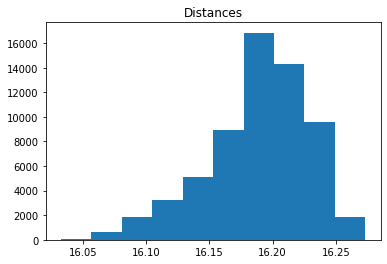

In [218]:
plt.hist(dists)
plt.title("Distances")
plt.show()

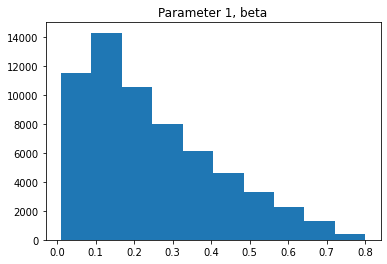

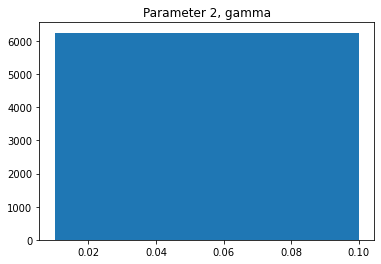

Overall mean of par1 (beta or net transmission) 0.24750027500000005
Overall mean of par2 (gamma or R) 0.05500000000000001


In [221]:
plt.hist(pairs[:,0])
plt.title("Parameter 1, beta") # or net transmission
plt.show()

plt.hist(pairs[:,1])
plt.title("Parameter 2, gamma") # or R
plt.show()

print("Overall mean of par1 (beta or net transmission)", np.mean(pairs[:,0]))
print("Overall mean of par2 (gamma or R)", np.mean(pairs[:,1]))

In [226]:
# Print point estimates:
eps =16.1
print(f"Beta mean: {np.mean(pairs[np.where(dists< eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs[np.where(dists < eps)[0],0])/np.mean(pairs[np.where(dists < eps)[0],1])}")
print(f"True parameters (for synthetic data): beta = {true_par1}, gamma = {true_par2}")

Beta mean: 0.07586436405634066
Gamma mean: 0.013117234451781546
R = beta mean/gamma mean: 5.783563931499065
True parameters (for synthetic data): beta = None, gamma = None


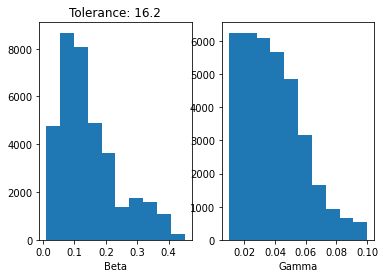

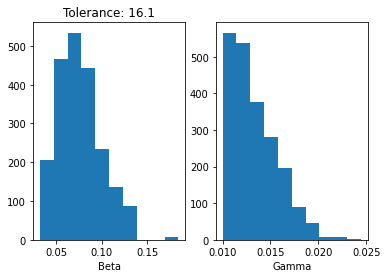

In [228]:
# Visualize:
plot_histograms(dists, pairs[:,0], pairs[:,1], 16.2, save = True, filename = res_root + "tolerance_hist_test.pdf")
plot_histograms(dists, pairs[:,0], pairs[:,1], 16.1, save = True, filename = res_root + "tolerance_hist_test.pdf")

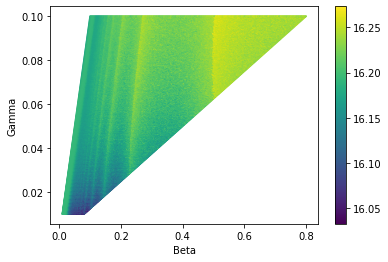

In [229]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_par1, true_gamma = true_par2,\
                        save = True, filename = res_root + "grid_scatter_test.pdf")

2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


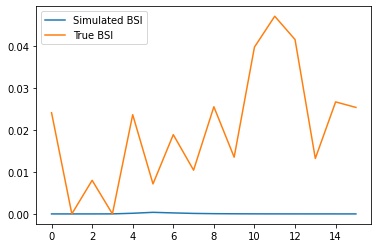

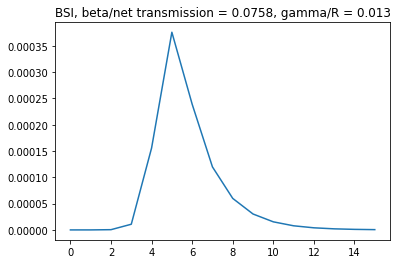

In [233]:
from cluster.scripts.load_data import *
n_weeks = 16*52
pop_size = 5000000
obs_data = "NORM"
clade = "A"

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}
bsi_real_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)


plt.plot(bsi_real_sim[0], label = "Simulated BSI") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.
plt.plot(np.array(bsi_obs_data), label = "True BSI")
plt.legend()
plt.show()

plt.plot(bsi_real_sim[0])
plt.title(f"BSI, beta/net transmission = {true_par1}, gamma/R = {true_par2}")
plt.show()

### Aggregate example

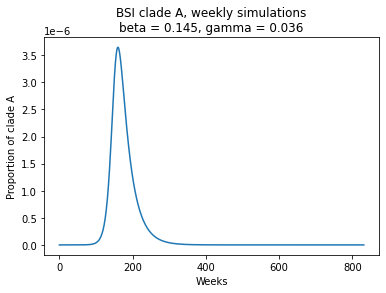

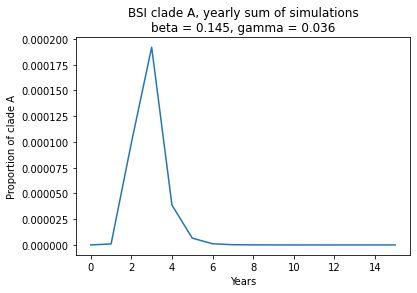

In [238]:
true_par1 = 0.145
true_par2 = 0.036

bsi_sim_agg = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)
bsi_sim = SIR_and_BSI_simulator(np.array([true_par1]), np.array([true_par2]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)



plt.plot(bsi_sim[0])
plt.title(f"BSI clade A, weekly simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Weeks")
plt.show()

plt.plot(bsi_sim_agg[0])
plt.title(f"BSI clade A, yearly sum of simulations\nbeta = {true_par1}, gamma = {true_par2}")
plt.ylabel("Proportion of clade A")
plt.xlabel("Years")
plt.show()